# Distribution

Need to look at distruibution etc of training set ONLY, so we load up training data for both abundances:

In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('..')
from Utilities import custom
from sklearn.model_selection import train_test_split
from IPython.core.magic import register_cell_magic
import matplotlib as mpl
import matplotlib.pyplot as plt

@register_cell_magic
def skip(line, cell):
    return

plots_folder='../Plots/basic_properties_distribution'
oxy, na=custom.data_loader('O/Fe', xysplit=False), custom.data_loader('Na/Fe', xysplit=False)

In [2]:
oxy

,NGC,Paper,Author Reference,RAJ2000,DEJ2000,Distance (pc),neg_sigma_dist,pos_sigma_dist,Vmag,Vmag_abs,...,F336W_e,F438W,F438W_abs,F438W_e,F606W,F606W_abs,F606W_e,F814W,F814W_abs,F814W_e
Star ID,,,,,,,,,,,,,,,,,,,,,
R0018794,104,Carretta,26058,6.028079,-72.073897,4521,-31,31,12.403,-0.873173,...,0.0000,13.7323,0.456127,0.0000,12.0009,-1.275273,0.0000,10.9820,-2.294173,0.0000
R0025327,104,Carretta,30340,6.011504,-72.055008,4521,-31,31,12.395,-0.881173,...,0.0000,13.8185,0.542327,0.0000,12.0301,-1.246073,0.0000,10.9334,-2.342773,0.0000
R0001617,288,Carretta,200001,13.171308,-26.557431,8988,-88,89,11.380,-3.388315,...,0.0000,NaN,NaN,NaN,12.0358,-2.732515,0.0000,10.6808,-4.087515,0.0000
R0001265,288,Carretta,200014,13.208867,-26.570667,8988,-88,89,13.864,-0.904315,...,0.0006,15.0652,0.296885,0.0072,13.5954,-1.172915,0.0000,12.6846,-2.083715,0.0000
R0014452,288,Carretta,200015,13.188296,-26.582756,8988,-88,89,13.864,-0.904315,...,0.0027,21.8567,7.088385,0.0868,20.4380,5.669685,0.0649,19.5103,4.741985,0.0823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R0004711,7099,Carretta,9817,325.099733,-23.160014,8458,-89,90,14.720,0.083662,...,0.0036,15.6192,0.982862,0.0007,14.5634,-0.072938,0.0000,13.7918,-0.844538,0.0000
R0001536,7099,Carretta,9881,325.125488,-23.183806,8458,-89,90,14.753,0.116662,...,0.0000,NaN,NaN,NaN,14.5138,-0.122538,0.0000,13.7363,-0.900038,0.0000
R0002162,7099,Carretta,10153,325.109496,-23.181003,8458,-89,90,13.040,-1.596338,...,0.0000,14.1703,-0.466038,0.0000,12.7613,-1.875038,0.0000,11.8368,-2.799538,0.0000


In [3]:
na

,NGC,Paper,Author Reference,RAJ2000,DEJ2000,Distance (pc),neg_sigma_dist,pos_sigma_dist,Vmag,Vmag_abs,...,F336W_e,F438W,F438W_abs,F438W_e,F606W,F606W_abs,F606W_e,F814W,F814W_abs,F814W_e
Star ID,,,,,,,,,,,,,,,,,,,,,
R0011193,104,Carretta,23821,6.006462,-72.083161,4521,-31,31,12.832,-0.444173,...,0.0000,14.0887,0.812527,0.0000,12.4808,-0.795373,0.0,11.4993,-1.776873,0.0
R0015269,104,Carretta,24901,6.086121,-72.078614,4521,-31,31,13.975,0.698827,...,0.0000,15.0095,1.733327,0.0000,13.6955,0.419327,0.0,12.8655,-0.410673,0.0
R0018788,104,Carretta,25988,6.078467,-72.073897,4521,-31,31,13.457,0.180827,...,0.0000,14.7838,1.507627,0.0000,13.1290,-0.147173,0.0,12.2317,-1.044473,0.0
R0018794,104,Carretta,26058,6.028079,-72.073897,4521,-31,31,12.403,-0.873173,...,0.0000,13.7323,0.456127,0.0000,12.0009,-1.275273,0.0,10.9820,-2.294173,0.0
R0024168,104,Carretta,29031,6.102871,-72.060739,4521,-31,31,14.571,1.294827,...,0.0000,15.5521,2.275927,0.0000,14.3188,1.042627,0.0,13.5177,0.241527,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R0002687,7099,Carretta,10318,325.074583,-23.179286,8458,-89,90,15.294,0.657662,...,0.0085,16.0905,1.454162,0.0034,15.0886,0.452262,0.0,14.3552,-0.281138,0.0
R0002313,7099,Carretta,10831,325.097229,-23.180417,8458,-89,90,13.437,-1.199338,...,0.0000,14.4706,-0.165738,0.0000,13.1491,-1.487238,0.0,12.2758,-2.360538,0.0
R0004243,7099,Carretta,11311,325.097350,-23.169014,8458,-89,90,13.204,-1.432338,...,0.0000,14.2793,-0.357038,0.0000,12.9244,-1.711938,0.0,12.0206,-2.615738,0.0


array([[<Axes: title={'center': 'O/Fe'}>]], dtype=object)

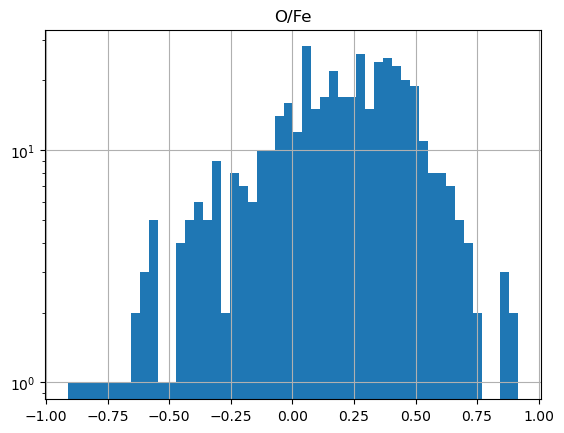

In [4]:
oxy.hist(column='O/Fe', log=True, bins=50)

array([[<Axes: title={'center': 'Na/Fe'}>]], dtype=object)

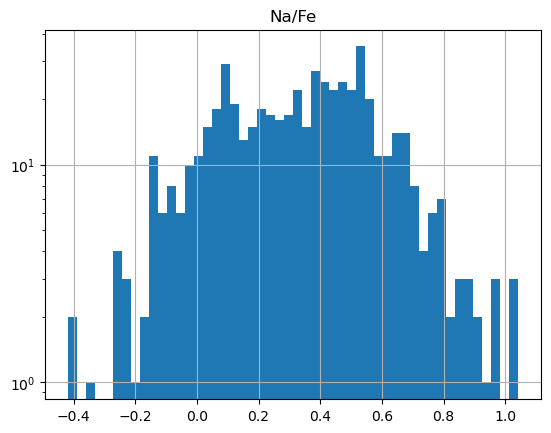

In [5]:
na.hist(column='Na/Fe', log=True, bins=50)

It looks like our -0.6 sodium outlier is in our official test set....interesting. 

We should have enough data to cover from -0.75 to 0.75 for oxygen and -0.3 to 1 for sodium:
CHECK IF STILL TRUE

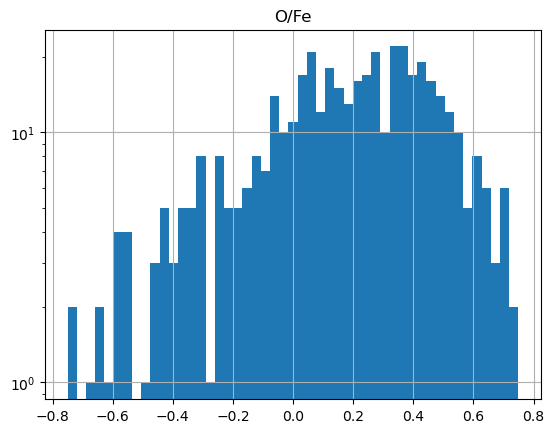

In [6]:
bins=np.linspace(-0.75, 0.75, 50)
oxy.hist(column='O/Fe', log=True, bins=bins)
plt.savefig(f'{plots_folder}/Oxygen_Points/O_abundance.png')

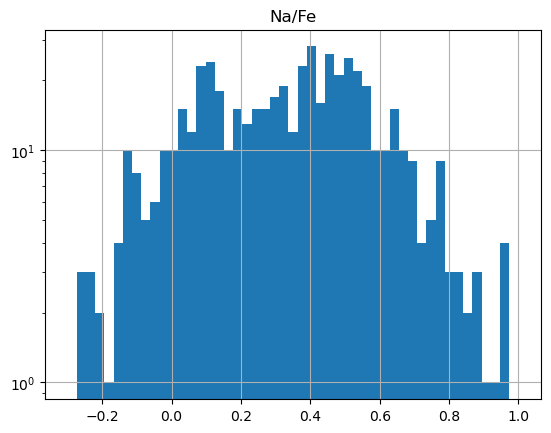

In [7]:
bins=np.linspace(-0.3, 1.0, 50)
na.hist(column='Na/Fe', log=True, bins=bins)
plt.savefig(f'{plots_folder}/Sodium_Points/Na_abundance.png')

### Age/Metallicity Distribution

Age:

array([[<Axes: title={'center': 'age_Kruijssen'}>]], dtype=object)

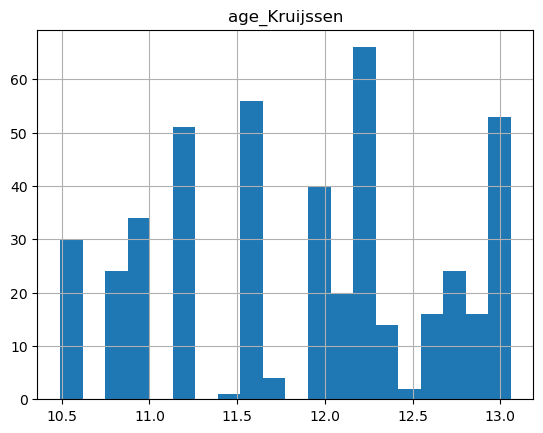

In [8]:
oxy.hist(column='age_Kruijssen', bins=20)

array([[<Axes: title={'center': 'age_Kruijssen'}>]], dtype=object)

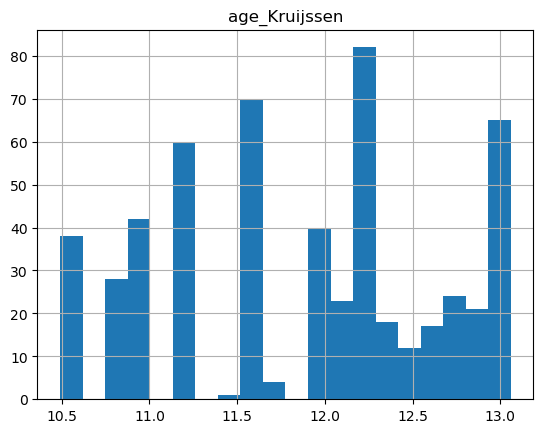

In [9]:
na.hist(column='age_Kruijssen', bins=20)

In both cases, about 50/50 split between older and younger clusters. Jeremy suggested we look at age/metallicity in 2D to ensure even sampling: 

Text(0.5, 1.0, 'Oxygen Points')

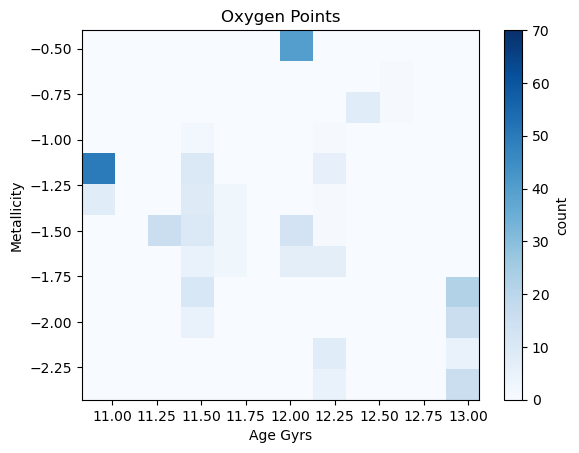

In [10]:
df_2d_hist=oxy.dropna(subset=['age_Kruijssen', 'Fe/H'], how='any')
plt.hist2d(df_2d_hist['age_Kruijssen'], df_2d_hist['Fe/H'], bins=12, vmin=0, vmax=70, cmap='Blues')
plt.colorbar(label='count')
plt.xlabel('Age Gyrs')
plt.ylabel('Metallicity')
plt.title('Oxygen Points')

Text(0.5, 1.0, 'Sodium Points')

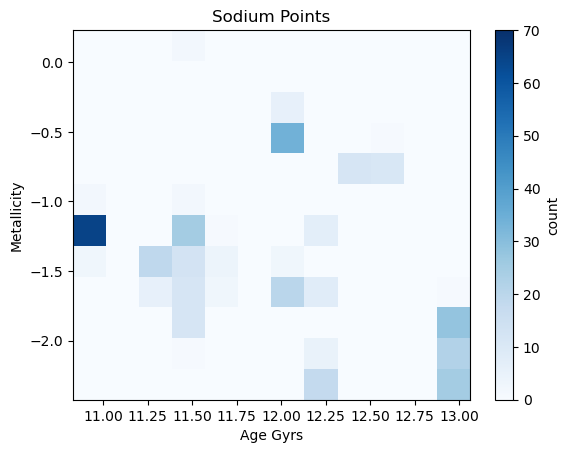

In [11]:
df_2d_hist=na.dropna(subset=['age_Kruijssen', 'Fe/H'], how='any')
plt.hist2d(df_2d_hist['age_Kruijssen'], df_2d_hist['Fe/H'], bins=12, vmin=0, vmax=70, cmap='Blues')
plt.colorbar(label='count')
plt.xlabel('Age Gyrs')
plt.ylabel('Metallicity')
plt.title('Sodium Points')

In [12]:
oxy.columns

Index(['NGC', 'Paper', 'Author Reference', 'RAJ2000', 'DEJ2000',
       'Distance (pc)', 'neg_sigma_dist', 'pos_sigma_dist', 'Vmag', 'Vmag_abs',
       'Bmag', 'Bmag_abs', 'Imag', 'Imag_abs', 'Kmag', 'Kmag_abs', 'Teff',
       'logg', 'age_Kruijssen', 'Fe/H', 'Fe/H_e', 'Fe/H_o', 'O/Fe', 'O/Fe_e',
       'Na/Fe', 'Na/Fe_e', 'F275W', 'F275W_abs', 'F275W_e', 'F336W',
       'F336W_abs', 'F336W_e', 'F438W', 'F438W_abs', 'F438W_e', 'F606W',
       'F606W_abs', 'F606W_e', 'F814W', 'F814W_abs', 'F814W_e'],
      dtype='object')

### Check for Oxygen/Sodium Anti-Correlation

<Axes: title={'center': 'Oxygen Points'}, xlabel='Na/Fe', ylabel='O/Fe'>

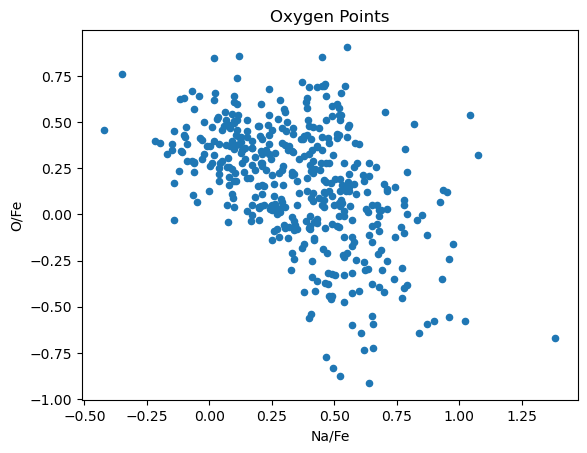

In [13]:
oxy.plot(kind='scatter', x='Na/Fe', y='O/Fe', title='Oxygen Points')

<Axes: title={'center': 'Sodium Points'}, xlabel='Na/Fe', ylabel='O/Fe'>

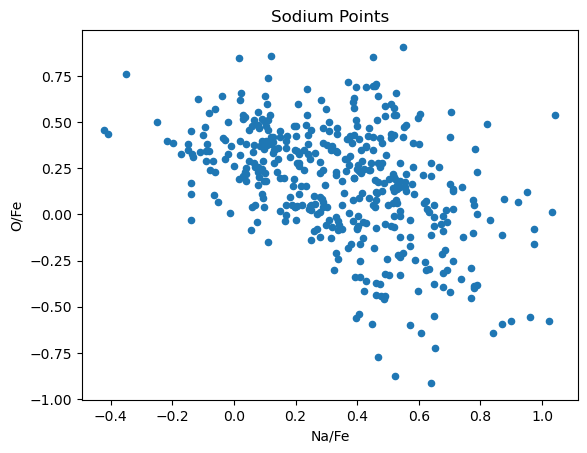

In [14]:
na.plot(kind='scatter', x='Na/Fe', y='O/Fe', title='Sodium Points')

The anticorrelation is strong! But we can't use an abundance as an input. We would need a multivariate model that includes the anti-correlation as part of the cost function. 

In [15]:
from pandas.plotting import scatter_matrix
filters=[column for column in oxy.columns if 'W_abs' in column]
other_xs=['Fe/H', 'age_Kruijssen']
ys=['Na/Fe', 'O/Fe']
attributes=filters+other_xs+ys

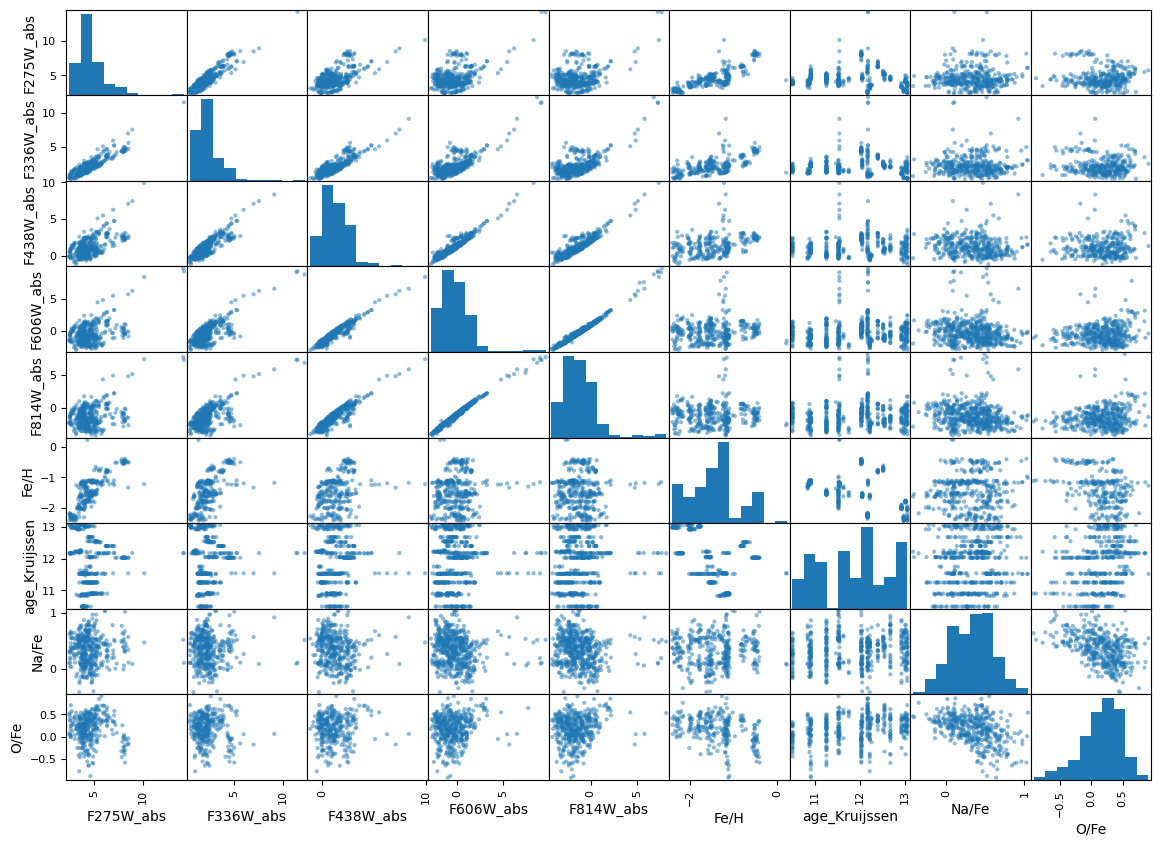

In [16]:
scatter_matrix(na[attributes], figsize=(14, 10))
plt.show()

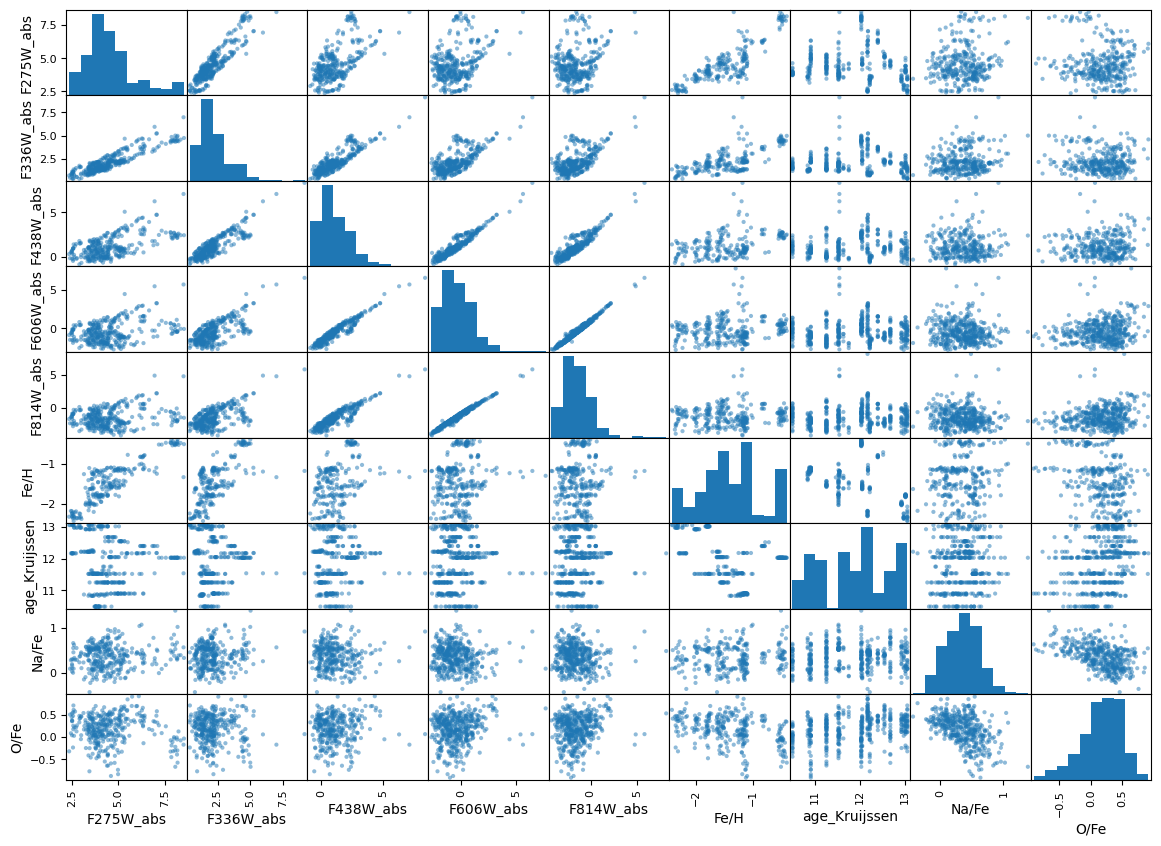

In [17]:
scatter_matrix(oxy[attributes], figsize=(14, 10))
plt.show()

In [30]:
na[attributes].describe()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen,Na/Fe,O/Fe
count,402.000000,401.000000,390.000000,537.000000,540.000000,371.000000,545.000000,545.000000,423.000000
mean,4.609902,2.312279,1.280100,-0.159116,-1.203128,-1.425423,11.869303,0.334584,0.168343
std,1.481058,1.420281,1.363106,1.800031,1.808872,0.550560,0.774834,0.265839,0.314696
min,2.412162,0.377162,-1.161438,-2.883138,-4.195690,-2.425000,10.490000,-0.420000,-0.913000
25%,3.765272,1.460779,0.347094,-1.304520,-2.348680,-1.811500,11.250000,0.120000,-0.010250
50%,4.293343,2.082585,1.075661,-0.405858,-1.483709,-1.457000,12.030000,0.361000,0.210000
75%,5.072915,2.667227,2.029501,0.627355,-0.287757,-1.131500,12.520000,0.520000,0.391500
max,14.220168,12.240468,9.921285,9.645368,8.108690,0.231000,13.060000,1.043150,0.908415


The filters are strongly correlated with nearby filters (ie, F275 and F336), but less correlated with more distant filters. Need to weight them differently when doing imputation. Different filters have different useful correlations.

Probably only use Metallicity also pretty correlated at low wavelengths, but less at high. I would say use it fro 275 and 336 but not others. 

275: 336, 438, Fe/H (maybe Fe/H before 438)

336: 275, 438, 606, 814, Fe/H (maybe Fe/H before 814)

438: 606, 814, 336, 275, Fe/H

606: 814, 438, 336 (Fe/H not very correlated)

814: 606, 438, 336 (Fe/H not very correlated)

Honestly let's just calculate correlation coefficients:

In [18]:
oxy[attributes].corr()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen,Na/Fe,O/Fe
F275W_abs,1.000000,0.898389,0.586346,0.339116,0.230037,0.859253,-0.073092,0.141159,-0.087394
F336W_abs,0.898389,1.000000,0.879652,0.709153,0.618639,0.677320,-0.009193,0.169349,-0.068975
F438W_abs,0.586346,0.879652,1.000000,0.957175,0.914139,0.383268,0.051399,0.027129,0.067190
F606W_abs,0.339116,0.709153,0.957175,1.000000,0.991066,0.158746,0.082699,-0.066480,0.169841
F814W_abs,0.230037,0.618639,0.914139,0.991066,1.000000,0.062761,0.081826,-0.075282,0.183859
Fe/H,0.859253,0.677320,0.383268,0.158746,0.062761,1.000000,-0.415110,0.098798,-0.360929
age_Kruijssen,-0.073092,-0.009193,0.051399,0.082699,0.081826,-0.415110,1.000000,0.075102,0.288858
Na/Fe,0.141159,0.169349,0.027129,-0.066480,-0.075282,0.098798,0.075102,1.000000,-0.480504
O/Fe,-0.087394,-0.068975,0.067190,0.169841,0.183859,-0.360929,0.288858,-0.480504,1.000000


In [19]:
na[attributes].corr()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen,Na/Fe,O/Fe
F275W_abs,1.000000,0.903831,0.593520,0.486564,0.391445,0.797152,-0.046647,0.032788,-0.072408
F336W_abs,0.903831,1.000000,0.874924,0.784440,0.707106,0.627638,0.020390,0.005262,-0.063141
F438W_abs,0.593520,0.874924,1.000000,0.960120,0.922212,0.342577,0.056605,-0.102665,0.054587
F606W_abs,0.486564,0.784440,0.960120,1.000000,0.991969,0.100482,0.088936,-0.132512,0.151700
F814W_abs,0.391445,0.707106,0.922212,0.991969,1.000000,0.023991,0.093777,-0.143223,0.162067
Fe/H,0.797152,0.627638,0.342577,0.100482,0.023991,1.000000,-0.414081,0.033572,-0.360628
age_Kruijssen,-0.046647,0.020390,0.056605,0.088936,0.093777,-0.414081,1.000000,0.119822,0.265989
Na/Fe,0.032788,0.005262,-0.102665,-0.132512,-0.143223,0.033572,0.119822,1.000000,-0.443627
O/Fe,-0.072408,-0.063141,0.054587,0.151700,0.162067,-0.360628,0.265989,-0.443627,1.000000


In [20]:
oxy[attributes].corr()-na[attributes].corr()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen,Na/Fe,O/Fe
F275W_abs,0.000000,-0.005442,-0.007173,-0.147449,-0.161409,0.062101,-0.026445,0.108371,-0.014985
F336W_abs,-0.005442,0.000000,0.004728,-0.075287,-0.088467,0.049681,-0.029583,0.164086,-0.005833
F438W_abs,-0.007173,0.004728,0.000000,-0.002946,-0.008073,0.040691,-0.005206,0.129794,0.012603
F606W_abs,-0.147449,-0.075287,-0.002946,0.000000,-0.000903,0.058263,-0.006237,0.066032,0.018141
F814W_abs,-0.161409,-0.088467,-0.008073,-0.000903,0.000000,0.038770,-0.011952,0.067940,0.021793
Fe/H,0.062101,0.049681,0.040691,0.058263,0.038770,0.000000,-0.001029,0.065226,-0.000300
age_Kruijssen,-0.026445,-0.029583,-0.005206,-0.006237,-0.011952,-0.001029,0.000000,-0.044720,0.022870
Na/Fe,0.108371,0.164086,0.129794,0.066032,0.067940,0.065226,-0.044720,0.000000,-0.036877
O/Fe,-0.014985,-0.005833,0.012603,0.018141,0.021793,-0.000300,0.022870,-0.036877,0.000000


The amount of correlation in the two datasets is similar. It is more different for less correlated attributes, which is good, because we will probably not use those anyhow. 

Want to weight KNN by correlation coefficicents. But, scaling data could change correlations. Should I use my knowledge of these "real" correlations or scale data, then calculate this? Let's try a simple data rescaling:

In [21]:
from sklearn.preprocessing import RobustScaler
na_scaler=RobustScaler().fit(na[attributes])
oxy_scaler=RobustScaler().fit(oxy[attributes])

In [22]:
na_scaled=pd.DataFrame(na_scaler.transform(na[attributes]), columns=attributes)
na_scaled.corr()-na[attributes].corr()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen,Na/Fe,O/Fe
F275W_abs,0.000000e+00,-4.440892e-16,-5.551115e-16,1.110223e-16,-3.885781e-16,0.000000e+00,-9.020562e-17,-1.249001e-16,2.775558e-17
F336W_abs,-4.440892e-16,0.000000e+00,-1.110223e-15,1.665335e-15,-5.551115e-16,1.110223e-16,5.204170e-16,-1.795439e-16,-5.551115e-17
F438W_abs,-5.551115e-16,-1.110223e-15,0.000000e+00,1.110223e-16,8.881784e-16,3.885781e-16,-1.193490e-15,1.387779e-16,-1.665335e-16
F606W_abs,1.110223e-16,1.665335e-15,1.110223e-16,0.000000e+00,3.330669e-16,1.526557e-16,-1.387779e-17,0.000000e+00,-5.551115e-17
F814W_abs,-3.885781e-16,-5.551115e-16,8.881784e-16,3.330669e-16,0.000000e+00,9.714451e-17,-1.512679e-15,-1.110223e-16,3.053113e-16
Fe/H,0.000000e+00,1.110223e-16,3.885781e-16,1.526557e-16,9.714451e-17,0.000000e+00,-1.387779e-15,-6.938894e-17,-1.110223e-16
age_Kruijssen,-9.020562e-17,5.204170e-16,-1.193490e-15,-1.387779e-17,-1.512679e-15,-1.387779e-15,0.000000e+00,-1.110223e-16,5.551115e-17
Na/Fe,-1.249001e-16,-1.795439e-16,1.387779e-16,0.000000e+00,-1.110223e-16,-6.938894e-17,-1.110223e-16,0.000000e+00,2.220446e-16
O/Fe,2.775558e-17,-5.551115e-17,-1.665335e-16,-5.551115e-17,3.053113e-16,-1.110223e-16,5.551115e-17,2.220446e-16,0.000000e+00


In [23]:
oxy_scaled=pd.DataFrame(oxy_scaler.transform(oxy[attributes]), columns=attributes)
oxy_scaled.corr()-oxy[attributes].corr()

,F275W_abs,F336W_abs,F438W_abs,F606W_abs,F814W_abs,Fe/H,age_Kruijssen,Na/Fe,O/Fe
F275W_abs,0.000000e+00,6.661338e-16,0.000000e+00,4.440892e-16,2.498002e-16,-5.551115e-16,7.216450e-16,-2.775558e-17,-4.163336e-17
F336W_abs,6.661338e-16,0.000000e+00,-3.330669e-16,-1.110223e-16,1.110223e-16,-3.330669e-16,3.625572e-16,1.665335e-16,-1.387779e-17
F438W_abs,0.000000e+00,-3.330669e-16,0.000000e+00,-2.220446e-16,-2.220446e-16,-1.110223e-16,-3.053113e-16,1.214306e-16,-9.714451e-17
F606W_abs,4.440892e-16,-1.110223e-16,-2.220446e-16,0.000000e+00,2.220446e-16,5.551115e-17,-7.910339e-16,-1.387779e-17,-2.775558e-17
F814W_abs,2.498002e-16,1.110223e-16,-2.220446e-16,2.220446e-16,0.000000e+00,-8.326673e-17,-7.077672e-16,2.775558e-17,-1.942890e-16
Fe/H,-5.551115e-16,-3.330669e-16,-1.110223e-16,5.551115e-17,-8.326673e-17,0.000000e+00,-5.551115e-16,5.551115e-17,5.551115e-17
age_Kruijssen,7.216450e-16,3.625572e-16,-3.053113e-16,-7.910339e-16,-7.077672e-16,-5.551115e-16,0.000000e+00,1.804112e-16,-1.665335e-16
Na/Fe,-2.775558e-17,1.665335e-16,1.214306e-16,-1.387779e-17,2.775558e-17,5.551115e-17,1.804112e-16,0.000000e+00,-5.551115e-17
O/Fe,-4.163336e-17,-1.387779e-17,-9.714451e-17,-2.775558e-17,-1.942890e-16,5.551115e-17,-1.665335e-16,-5.551115e-17,0.000000e+00


Aright good, so the correlation coefficient doesn't change hardly at all, even when scaling in the outliers. 

### Looking For Outliers in Inputs

Cannot really remove outliers in abundance because we don't know abundances! Looking for other cuts to make by plotting inputs vs outputs:

In [24]:
%%capture
for filter_ in filters:
    oxy.hist(column=filter_, log=True, bins=50)
    plt.savefig(f'{plots_folder}/Oxygen_Points/{filter_}_hist.png')
    na.hist(column=filter_, log=True, bins=50)
    plt.savefig(f'{plots_folder}/Oxygen_Points/{filter_}_hist.png')

    oxy.plot(kind='scatter', x=filter_, y='O/Fe', title=f'Oxygen Points, {filter_}')
    plt.savefig(f'{plots_folder}/Oxygen_Points/{filter_}.png')

    na.plot(kind='scatter', x=filter_, y='Na/Fe', title=f'Sodium Points, {filter_}')
    plt.savefig(f'{plots_folder}/Sodium_Points/{filter_}.png')

After looking at OXYGEN plots, note that more enriched stars have higher magntiude at high wavelength; not much correlation at low wavelength. O, F275W essentially uncorrelated. Maybe slight correlation in F336W, mostly in form of clustering at mid-abundance and low mag. However there are stronger relationships at higher wavelengths. In all foltyers besides F275W, ~3-5 points at high mag (low brightness) that do not correlate very well with abundance. HOWEVER these are not the same points each time because y values are different.....sigh....hopefuly not 20 completely different points

POssible cuts for each filter for OXYGEN:

F275W: None?
F336W: ~5.9
F438W: ~4.9
F606W: 4 (very clear separation)
F814W: 4 (very clear separation, ~3 points in common with above)

After looking at SODIUM plots, note less of a correlation with all filters in general. Honestly pretty blobby. But, usually fairly distinct division between well-sampled and sparsely-sampled data. HOWEVER many more points (~3-15) would be cut out using these cuts, and most of them are not common between filters.

POssible cuts for each filter in SODIUM:

F275W: 10, or even 9
F336W: ~7
F438W: ~6 (this one is less clear than others)
F606W: 



### Try Plotting Vs Distance

Suspicious that the secondary population is jusy dimmer, closer objects. Let's see:

<Axes: title={'center': 'Sodium Points'}, xlabel='Distance (pc)', ylabel='Na/Fe'>

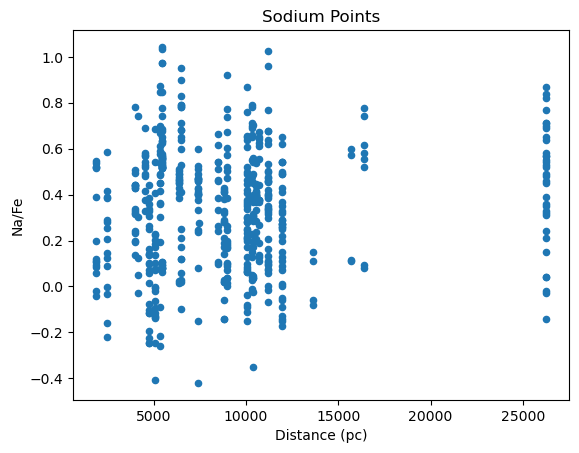

In [25]:
na.plot(kind='scatter', x='Distance (pc)', y='Na/Fe', title='Sodium Points')

<Axes: title={'center': 'Oxygen Points'}, xlabel='Distance (pc)', ylabel='O/Fe'>

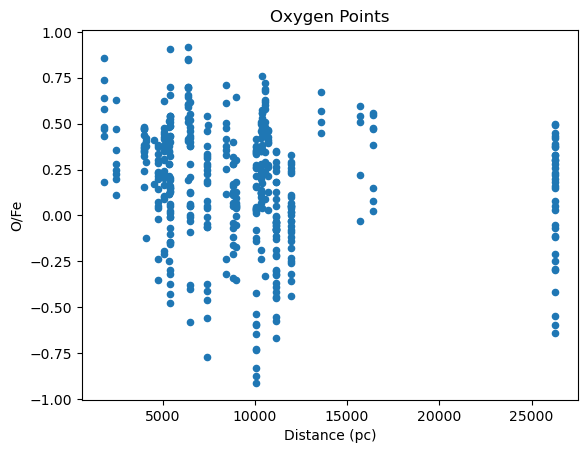

In [26]:
oxy.plot(kind='scatter', x='Distance (pc)', y='O/Fe', title='Oxygen Points')

Nothing in particular, although set of extra distant points (this would mean abolute magnitudes that are too bright, though, not too dim). Where are these points from?

Looking at sodium points, filter 606W has clear seperation at 4 mag

In [27]:
na[na['F606W_abs']>4]

,NGC,Paper,Author Reference,RAJ2000,DEJ2000,Distance (pc),neg_sigma_dist,pos_sigma_dist,Vmag,Vmag_abs,...,F336W_e,F438W,F438W_abs,F438W_e,F606W,F606W_abs,F606W_e,F814W,F814W_abs,F814W_e
Star ID,,,,,,,,,,,,,,,,,,,,,
R0014452,288,Carretta,200015,13.188296,-26.582756,8988,-88,89,13.864,-0.904315,...,0.0027,21.8567,7.088385,0.0868,20.4380,5.669685,0.0649,19.5103,4.741985,0.0823
R0006235,288,Carretta,200064,13.211992,-26.598058,8988,-88,89,15.029,0.260685,...,0.0000,23.1100,8.341685,0.0000,21.2970,6.528685,0.0909,20.5532,5.784885,0.0942
R0002469,288,Carretta,200091,13.168042,-26.609028,8988,-88,89,15.379,0.610685,...,0.0000,19.8505,5.082185,0.0000,19.2043,4.435985,0.0037,NaN,NaN,NaN
R0018661,288,Carretta,200141,13.201512,-26.574053,8988,-88,89,15.731,0.962685,...,0.0227,21.0286,6.260285,0.0525,20.2069,5.438585,0.0165,19.6108,4.842485,0.0193
R0016011,288,Carretta,200147,13.198479,-26.578697,8988,-88,89,15.789,1.020685,...,0.0039,20.2553,5.486985,0.0459,19.5444,4.776085,0.0092,19.0270,4.258685,0.0074
R0018310,288,Carretta,200193,13.163117,-26.573317,8988,-88,89,15.985,1.216685,...,NaN,24.6896,9.921285,0.0000,23.0967,8.328385,0.1012,22.0923,7.323985,0.0105
R0025332,288,Carretta,200226,13.168938,-26.555228,8988,-88,89,16.160,1.391685,...,NaN,NaN,NaN,NaN,23.7941,9.025785,0.0000,22.3180,7.549685,0.0424
R0026914,288,Carretta,200263,13.193454,-26.548019,8988,-88,89,16.336,1.567685,...,NaN,NaN,NaN,NaN,22.5148,7.746485,0.0374,NaN,NaN,NaN
R0003704,6121,Dorazi + Marino,30209,245.892435,-26.546815,1851,-16,15,NaN,NaN,...,0.0000,NaN,NaN,NaN,20.4285,9.091468,0.0839,18.5690,7.231968,0.0296


and in filter 814 at 3 mag:

In [28]:
na[na['F814W_abs']>3]

,NGC,Paper,Author Reference,RAJ2000,DEJ2000,Distance (pc),neg_sigma_dist,pos_sigma_dist,Vmag,Vmag_abs,...,F336W_e,F438W,F438W_abs,F438W_e,F606W,F606W_abs,F606W_e,F814W,F814W_abs,F814W_e
Star ID,,,,,,,,,,,,,,,,,,,,,
R0014452,288,Carretta,200015,13.188296,-26.582756,8988,-88,89,13.864,-0.904315,...,0.0027,21.8567,7.088385,0.0868,20.4380,5.669685,0.0649,19.5103,4.741985,0.0823
R0006235,288,Carretta,200064,13.211992,-26.598058,8988,-88,89,15.029,0.260685,...,0.0000,23.1100,8.341685,0.0000,21.2970,6.528685,0.0909,20.5532,5.784885,0.0942
R0018661,288,Carretta,200141,13.201512,-26.574053,8988,-88,89,15.731,0.962685,...,0.0227,21.0286,6.260285,0.0525,20.2069,5.438585,0.0165,19.6108,4.842485,0.0193
R0016011,288,Carretta,200147,13.198479,-26.578697,8988,-88,89,15.789,1.020685,...,0.0039,20.2553,5.486985,0.0459,19.5444,4.776085,0.0092,19.0270,4.258685,0.0074
R0018310,288,Carretta,200193,13.163117,-26.573317,8988,-88,89,15.985,1.216685,...,NaN,24.6896,9.921285,0.0000,23.0967,8.328385,0.1012,22.0923,7.323985,0.0105
R0025332,288,Carretta,200226,13.168938,-26.555228,8988,-88,89,16.160,1.391685,...,NaN,NaN,NaN,NaN,23.7941,9.025785,0.0000,22.3180,7.549685,0.0424
R0003704,6121,Dorazi + Marino,30209,245.892435,-26.546815,1851,-16,15,NaN,NaN,...,0.0000,NaN,NaN,NaN,20.4285,9.091468,0.0839,18.5690,7.231968,0.0296
R0000410,6121,Dorazi + Marino,30653,245.887933,-26.541841,1851,-16,15,NaN,NaN,...,0.0371,18.7827,7.445668,0.0026,17.5431,6.206068,0.0078,16.4106,5.073568,0.0188
R0005009,6121,Dorazi + Marino,30924,245.896243,-26.538834,1851,-16,15,NaN,NaN,...,0.0000,NaN,NaN,NaN,20.5441,9.207068,0.2398,18.5475,7.210468,0.0953
